# Synthetic Graph EDA

In [1]:
import os
from dgl import save_graphs, load_graphs
from dgl.data.utils import makedirs, save_info, load_info
import networkx as nx

/home/eirik/miniconda3/envs/bigg/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Config
ORG_DATASET = "tolokers"
SYN_DATASET = "bigg_tolokers_blksize_128_b_5"

## Original Graph

In [4]:
PATH = f'../datasets/original/{ORG_DATASET}'
original_graph, _ = load_graphs(PATH)
 
original_graph = original_graph[0]

In [5]:
org_graph_num_nodes = original_graph.num_nodes()
org_graph_num_edges = original_graph.num_edges()
org_graph_num_anomalies = original_graph.ndata['label'].tolist().count(1)

org_graph_ndata_keys = list(original_graph.ndata.keys())
org_graph_train_masks_shape = original_graph.ndata['train_masks'].shape

## Synthetic Graph

In [6]:
synthetic_path = f'../datasets/synthetic/{SYN_DATASET}'
synthetic_graph, _ = load_graphs(synthetic_path)

synthetic_graph = synthetic_graph[0]

In [7]:
syn_graph_num_nodes = synthetic_graph.num_nodes()
syn_graph_num_edges = synthetic_graph.num_edges()
syn_graph_num_anomalies = synthetic_graph.ndata['label'].tolist().count(1)

syn_graph_ndata_keys = list(synthetic_graph.ndata.keys())
if 'train_masks' in synthetic_graph.ndata:
    syn_graph_train_masks_shape = synthetic_graph.ndata['train_masks'].shape

## Summary

In [8]:
print("--- Original Graph Summary ---")
print("Number of nodes:", org_graph_num_nodes)
print("Number of edges:", org_graph_num_edges)
print("Number of anomalies:", org_graph_num_anomalies)

print("\nAll ndata keys:", org_graph_ndata_keys)
print("train_masks shape:", org_graph_train_masks_shape)

--- Original Graph Summary ---
Number of nodes: 11758
Number of edges: 530758
Number of anomalies: 2566

All ndata keys: ['feature', 'label', 'train_masks', 'val_masks', 'test_masks']
train_masks shape: torch.Size([11758, 20])


In [10]:
print("--- Synthetic Graph Summary ---")
print("Number of nodes:", syn_graph_num_nodes)
print("Number of edges:", syn_graph_num_edges)
print("Number of anomalies:", syn_graph_num_anomalies)

print("\nAll ndata keys:", syn_graph_ndata_keys)
if 'train_masks' in synthetic_graph.ndata:
    print("train_masks shape:", syn_graph_train_masks_shape)
else:
    print("train_masks not found in synthetic graph data.")

--- Synthetic Graph Summary ---
Number of nodes: 11758
Number of edges: 477786
Number of anomalies: 2359

All ndata keys: ['test_masks', 'val_masks', 'train_masks', 'label', 'feature']
train_masks shape: torch.Size([11758, 20])


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# Convert DGL graphs to simple undirected NetworkX graphs
# (to_networkx returns a MultiDiGraph; nx.Graph() collapses multi-edges)
org_nx = nx.Graph(original_graph.to_networkx())
syn_nx = nx.Graph(synthetic_graph.to_networkx())

## Degree Distribution

Original  — mean: 90.28, median: 32.0, max: 2140
Synthetic — mean: 40.63, median: 31.0, max: 405


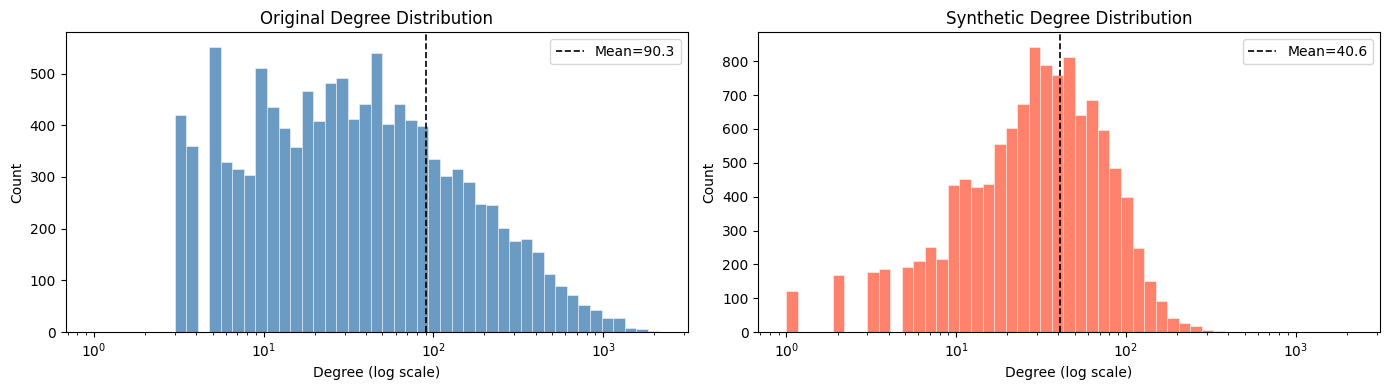

In [12]:
org_degrees = [d for _, d in org_nx.degree()]
syn_degrees = [d for _, d in syn_nx.degree()]

print(f"Original  — mean: {np.mean(org_degrees):.2f}, median: {np.median(org_degrees):.1f}, max: {max(org_degrees)}")
print(f"Synthetic — mean: {np.mean(syn_degrees):.2f}, median: {np.median(syn_degrees):.1f}, max: {max(syn_degrees)}")

max_degree = max(max(org_degrees), max(syn_degrees))
bins = np.logspace(0, np.log10(max_degree + 1), 50)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

for ax, degrees, label, color in zip(
    axes,
    [org_degrees, syn_degrees],
    ["Original", "Synthetic"],
    ["steelblue", "tomato"],
):
    ax.hist(degrees, bins=bins, color=color, alpha=0.8, edgecolor="white", linewidth=0.4)
    ax.set_xscale("log")
    ax.set_xlabel("Degree (log scale)")
    ax.set_ylabel("Count")
    ax.set_title(f"{label} Degree Distribution")
    ax.axvline(np.mean(degrees), color="black", linestyle="--", linewidth=1.2, label=f"Mean={np.mean(degrees):.1f}")
    ax.legend()

plt.tight_layout()
plt.show()

## Clustering Coefficient

Original  — average clustering coefficient: 0.5329
Synthetic — average clustering coefficient: 0.0092


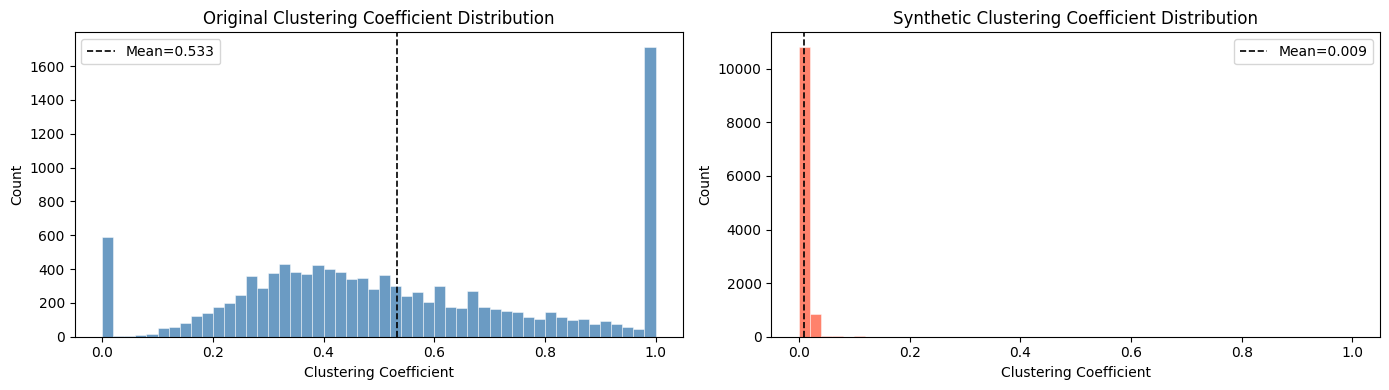

In [13]:
# Global (average) clustering coefficient
# Note: can be slow on large graphs; uses approximation via sampling if needed
org_avg_cc = nx.average_clustering(org_nx)
syn_avg_cc = nx.average_clustering(syn_nx)

print(f"Original  — average clustering coefficient: {org_avg_cc:.4f}")
print(f"Synthetic — average clustering coefficient: {syn_avg_cc:.4f}")

# Per-node distribution
org_cc = list(nx.clustering(org_nx).values())
syn_cc = list(nx.clustering(syn_nx).values())

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

for ax, cc_vals, label, color in zip(
    axes,
    [org_cc, syn_cc],
    ["Original", "Synthetic"],
    ["steelblue", "tomato"],
):
    ax.hist(cc_vals, bins=50, color=color, alpha=0.8, edgecolor="white", linewidth=0.4)
    ax.set_xlabel("Clustering Coefficient")
    ax.set_ylabel("Count")
    ax.set_title(f"{label} Clustering Coefficient Distribution")
    ax.axvline(np.mean(cc_vals), color="black", linestyle="--", linewidth=1.2, label=f"Mean={np.mean(cc_vals):.3f}")
    ax.legend()

plt.tight_layout()
plt.show()

## Feature Distribution

In [ ]:
org_feats = original_graph.ndata['feature'].numpy()   # shape [N, feat_dim]
syn_feats = synthetic_graph.ndata['feature'].numpy()

feat_dim = org_feats.shape[1]
print(f"Feature dimensionality: {feat_dim}")

# Summary stats per feature
print(f"\n{'Feature':>8} | {'Org mean':>10} {'Org std':>8} | {'Syn mean':>10} {'Syn std':>8}")
print("-" * 56)
for i in range(feat_dim):
    print(f"{i:>8} | {org_feats[:, i].mean():>10.4f} {org_feats[:, i].std():>8.4f} | "
          f"{syn_feats[:, i].mean():>10.4f} {syn_feats[:, i].std():>8.4f}")

In [ ]:
# Plot per-feature distributions (original vs synthetic overlay)
ncols = 4
nrows = (feat_dim + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
axes = axes.flatten()

for i in range(feat_dim):
    ax = axes[i]
    ax.hist(org_feats[:, i], bins=50, alpha=0.6, label="Original", color="steelblue", density=True)
    ax.hist(syn_feats[:, i], bins=50, alpha=0.6, label="Synthetic", color="tomato", density=True)
    ax.set_title(f"Feature {i}")
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    if i == 0:
        ax.legend()

# Hide unused subplots
for j in range(feat_dim, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Per-Feature Distributions: Original vs Synthetic", y=1.02)
plt.tight_layout()
plt.show()

## Add Train/Val/Test Masks

In [ ]:
# import torch

# num_nodes = synthetic_graph.num_nodes()
# num_splits = graph.ndata['train_masks'].shape[1]  # 20

# synthetic_graph.ndata['train_masks'] = torch.ones(num_nodes, num_splits, dtype=torch.uint8)
# synthetic_graph.ndata['val_masks'] = torch.zeros(num_nodes, num_splits, dtype=torch.uint8)
# synthetic_graph.ndata['test_masks'] = torch.zeros(num_nodes, num_splits, dtype=torch.uint8)

# save_graphs(synthetic_path, [synthetic_graph])
# print("Saved with masks:", list(synthetic_graph.ndata.keys()))

Saved with masks: ['label', 'feature', 'train_masks', 'val_masks', 'test_masks']
